In [1]:
import pandas as pd

In [2]:
df=pd.DataFrame({'var1' : [4,5,6,7],
                'var2' : [1,6,7,5]})
df

,var1,var2
0,4,1
1,5,6
2,6,7
3,7,5


In [3]:
df['sum']=df['var1']+df['var2']/2
df

,var1,var2,sum
0,4,1,4.5
1,5,6,8.0
2,6,7,9.5
3,7,5,9.5


In [20]:
mpg=pd.read_csv('../../datasets/public/mpg.csv')

In [21]:
mpg=mpg.rename(columns={'cty':'city','hwy':'highway'})
mpg

,manufacturer,model,displ,year,cyl,trans,drv,city,highway,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


In [22]:
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,city,highway,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [23]:
# 여기서 total은 통합연비
mpg['total']=mpg['city']+mpg['highway']/2
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,city,highway,fl,category,total
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,32.5
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,35.5
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,35.5
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,36.0
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,29.0


In [24]:
# 평균을 구해주는 메서드

mpg['total'].mean()

np.float64(28.57905982905983)

In [25]:
sum(mpg['total']/len(mpg))

28.57905982905983

In [26]:
mpg['total'].describe()

count    234.000000
mean      28.579060
std        7.155624
min       15.000000
25%       22.500000
50%       29.000000
75%       32.875000
max       57.000000
Name: total, dtype: float64

<Axes: ylabel='Frequency'>

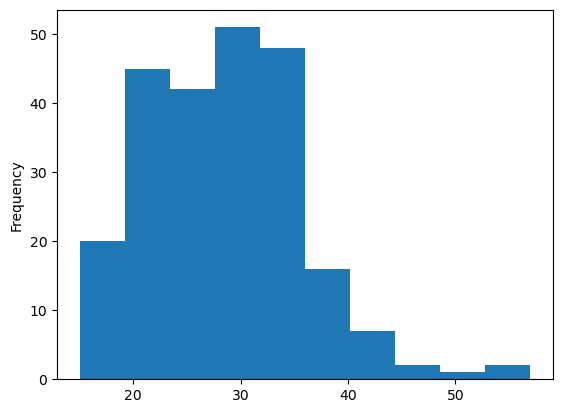

In [27]:
# df.plot.hist() 히스토그램을 만드는 메서드
mpg['total'].plot.hist()

In [28]:
# 대충 22~33에 많이 분포함
# 중앙값과 평균이 29정도 이므로 합격기준을 29로 잡기

In [29]:
import numpy as np
# 배열연산, 통계치 계산 등 수치연산을 할 때 자주 사용
# np 패키지의 where() 메서드를 이용하면 조건부여 가능
# np.where(조건, 조건 성립시 부여할 값, 성립하지 않을시 부여할 값)

In [32]:
mpg['test']=np.where(mpg['total']>=29, 'pass', 'fail')
mpg.tail(100)

,manufacturer,model,displ,year,cyl,trans,drv,city,highway,fl,category,total,test
134,lincoln,navigator 2wd,5.4,1999,8,auto(l4),r,11,17,r,suv,19.5,fail
135,lincoln,navigator 2wd,5.4,1999,8,auto(l4),r,11,16,p,suv,19.0,fail
136,lincoln,navigator 2wd,5.4,2008,8,auto(l6),r,12,18,r,suv,21.0,fail
137,mercury,mountaineer 4wd,4.0,1999,6,auto(l5),4,14,17,r,suv,22.5,fail
138,mercury,mountaineer 4wd,4.0,2008,6,auto(l5),4,13,19,r,suv,22.5,fail
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,33.0,pass
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,35.5,pass
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,29.0,pass
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,31.0,pass


In [33]:
# 빈도표로 합격판정 수 알아보기
# df.value_counts() 메서드 사용
mpg['test'].value_counts()

test
pass    121
fail    113
Name: count, dtype: int64

<Axes: xlabel='test'>

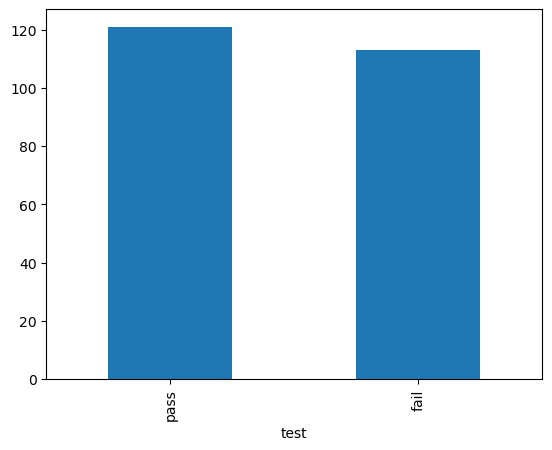

In [34]:
# df.plot.bar() 뒤에 바로 사용해도 됨
mpg['test'].value_counts().plot.bar()

<Axes: xlabel='test'>

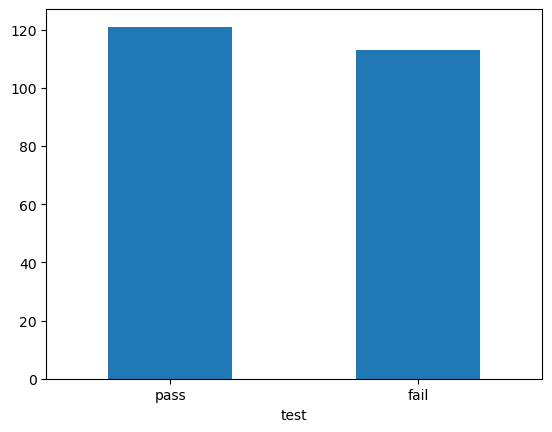

In [38]:
# 이름이 90도로 누워져있으므로 바로 세워주기
# 0이면 수평 / 기본값은 90
mpg['test'].value_counts().plot.bar(rot=0)

In [65]:
# 이번엔 중첩조건문으로 pass. fail말고 A B C등급으로 분류해보기
# np.where()안에 또다른 np.where()이 들어가있는 형태
mpg['grade']=np.where(mpg['total']>=35,'A'
                      ,np.where(mpg['total']>=30,'B'
                                ,np.where(mpg['total']>=20,'C'
                                         ,'D')))
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,city,highway,fl,category,total,test,grade
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,32.5,pass,B
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,35.5,pass,A
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,35.5,pass,A
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,36.0,pass,A
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,29.0,pass,C


<Axes: xlabel='grade'>

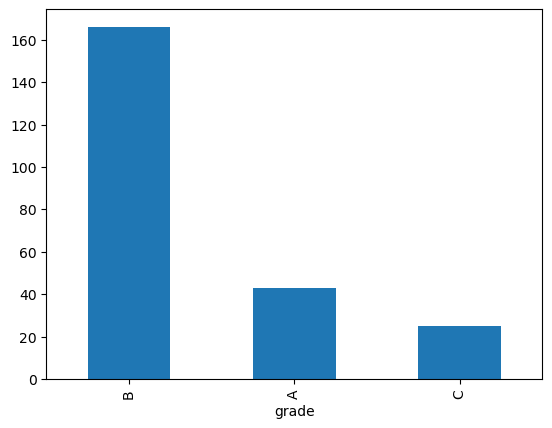

In [59]:
mpg['grade'].value_counts()
mpg['grade'].value_counts().plot.bar()

In [61]:
# 알파벳 순으로 정렬하기
mpg['grade'].value_counts().sort_index()


grade
A     43
B    166
C     25
Name: count, dtype: int64

<Axes: xlabel='grade'>

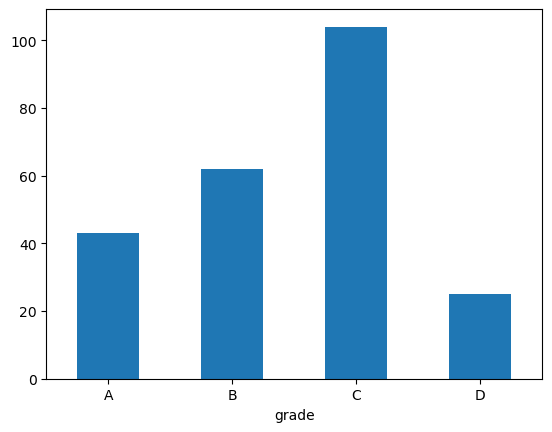

In [66]:
# 알파벳 순으로 정렬하기
mpg['grade'].value_counts().sort_index().plot.bar(rot=0)

In [70]:
# 여러 조건 중 하나에 해당하면 값을 할당하게 조건문을 작성해보자
mpg['size']=np.where((mpg['category']=='compact')|
                    (mpg['category']=='subcompact')|
                    (mpg['category']=='2seater'),'small','large')
mpg.tail(10)

,manufacturer,model,displ,year,cyl,trans,drv,city,highway,fl,category,total,test,grade,size
224,volkswagen,new beetle,2.0,1999,4,auto(l4),f,19,26,r,subcompact,32.0,pass,B,small
225,volkswagen,new beetle,2.5,2008,5,manual(m5),f,20,28,r,subcompact,34.0,pass,B,small
226,volkswagen,new beetle,2.5,2008,5,auto(s6),f,20,29,r,subcompact,34.5,pass,B,small
227,volkswagen,passat,1.8,1999,4,manual(m5),f,21,29,p,midsize,35.5,pass,A,large
228,volkswagen,passat,1.8,1999,4,auto(l5),f,18,29,p,midsize,32.5,pass,B,large
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,33.0,pass,B,large
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,35.5,pass,A,large
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,29.0,pass,C,large
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,31.0,pass,B,large
233,volkswagen,passat,3.6,2008,6,auto(s6),f,17,26,p,midsize,30.0,pass,B,large


<Axes: xlabel='size'>

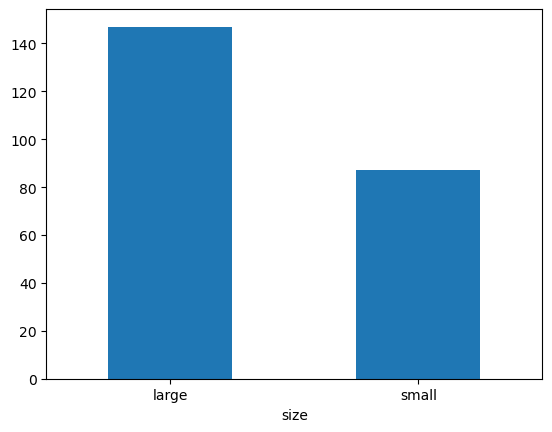

In [71]:
mpg['size'].value_counts().plot.bar(rot=0)